![A soccer pitch for an international match.](soccer-pitch.jpg)

You're working as a sports journalist at a major online sports media company, specializing in soccer analysis and reporting. You've been watching both men's and women's international soccer matches for a number of years, and your gut instinct tells you that more goals are scored in women's international football matches than men's. This would make an interesting investigative article that your subscribers are bound to love, but you'll need to perform a valid statistical hypothesis test to be sure!

While scoping this project, you acknowledge that the sport has changed a lot over the years, and performances likely vary a lot depending on the tournament, so you decide to limit the data used in the analysis to only official `FIFA World Cup` matches (not including qualifiers) since `2002-01-01`.

You create two datasets containing the results of every official men's and women's international football match since the 19th century, which you scraped from a reliable online source. This data is stored in two CSV files: `women_results.csv` and `men_results.csv`.

The question you are trying to determine the answer to is:

> Are more goals scored in women's international soccer matches than men's?

You assume a **10% significance level**, and use the following null and alternative hypotheses:

$H_0$ : The mean number of goals scored in women's international soccer matches is the same as men's.

$H_A$ : The mean number of goals scored in women's international soccer matches is greater than men's.

In [114]:
# Data preparation and inspection
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro
import pingouin as pg

df_women = pd.read_csv('women_results.csv')
df_men = pd.read_csv('men_results.csv')

df_women.head()

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament
0,0,1969-11-01,Italy,France,1,0,Euro
1,1,1969-11-01,Denmark,England,4,3,Euro
2,2,1969-11-02,England,France,2,0,Euro
3,3,1969-11-02,Italy,Denmark,3,1,Euro
4,4,1975-08-25,Thailand,Australia,3,2,AFC Championship


In [115]:
df_women.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4884 entries, 0 to 4883
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  4884 non-null   int64 
 1   date        4884 non-null   object
 2   home_team   4884 non-null   object
 3   away_team   4884 non-null   object
 4   home_score  4884 non-null   int64 
 5   away_score  4884 non-null   int64 
 6   tournament  4884 non-null   object
dtypes: int64(3), object(4)
memory usage: 267.2+ KB


In [116]:
df_women['tournament'].value_counts()

UEFA Euro qualification                 1445
Algarve Cup                              551
FIFA World Cup                           284
AFC Championship                         268
Cyprus Cup                               258
African Championship qualification       226
UEFA Euro                                184
African Championship                     173
FIFA World Cup qualification             172
CONCACAF Gold Cup qualification          143
AFC Asian Cup qualification              141
Copa América                             131
Olympic Games                            130
CONCACAF Gold Cup                        126
Friendly                                 111
AFC Asian Cup                            111
Four Nations Tournament                  106
OFC Championship                          78
African Cup of Nations qualification      58
CONCACAF Championship                     42
SheBelieves Cup                           39
Euro                                      20
African Cu

In [117]:
df_men.head()

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament
0,0,1872-11-30,Scotland,England,0,0,Friendly
1,1,1873-03-08,England,Scotland,4,2,Friendly
2,2,1874-03-07,Scotland,England,2,1,Friendly
3,3,1875-03-06,England,Scotland,2,2,Friendly
4,4,1876-03-04,Scotland,England,3,0,Friendly


In [118]:
df_men.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44353 entries, 0 to 44352
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  44353 non-null  int64 
 1   date        44353 non-null  object
 2   home_team   44353 non-null  object
 3   away_team   44353 non-null  object
 4   home_score  44353 non-null  int64 
 5   away_score  44353 non-null  int64 
 6   tournament  44353 non-null  object
dtypes: int64(3), object(4)
memory usage: 2.4+ MB


In [119]:
df_men['tournament'].value_counts()

Friendly                                17519
FIFA World Cup qualification             7878
UEFA Euro qualification                  2585
African Cup of Nations qualification     1932
FIFA World Cup                            964
                                        ...  
Real Madrid 75th Anniversary Cup            1
Évence Coppée Trophy                        1
Copa Confraternidad                         1
TIFOCO Tournament                           1
FIFA 75th Anniversary Cup                   1
Name: tournament, Length: 141, dtype: int64

## Great, now that I can see a general overview of the dataset. I can see that the date column is set to 'object' instead of datetime. It's time to filter the datasets to include only from the 'FIFA World Cup' tournament that takes place after 2002-01-01.

In [120]:
#Filtering the datasets
#Change date dtype from 'object' to 'datetime'
df_women_wc= df_women[df_women['tournament'].isin(['FIFA World Cup'])]
df_women_wc['date']=pd.to_datetime(df_women_wc['date'])
df_women_wc=df_women_wc[df_women_wc['date']>='2002-01-01']

df_men_wc= df_men[df_men['tournament'].isin(['FIFA World Cup'])]
df_men_wc['date']=pd.to_datetime(df_men_wc['date'])
df_men_wc=df_men_wc[df_men_wc['date']>='2002-01-01']


#Creating a total goals column for both groups
df_women_wc['total_goals']=df_women_wc['home_score']+df_women_wc['away_score']
df_men_wc['total_goals']=df_men_wc['home_score']+df_men_wc['away_score']

In [121]:
df_women_wc.head()

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,total_goals
1600,1600,2003-09-20,Nigeria,North Korea,0,3,FIFA World Cup,3
1601,1601,2003-09-20,Norway,France,2,0,FIFA World Cup,2
1602,1602,2003-09-20,Germany,Canada,4,1,FIFA World Cup,5
1603,1603,2003-09-20,Japan,Argentina,6,0,FIFA World Cup,6
1604,1604,2003-09-21,United States,Sweden,3,1,FIFA World Cup,4


In [122]:
df_men_wc.head()

,Unnamed: 0,date,home_team,away_team,home_score,away_score,tournament,total_goals
25164,25164,2002-05-31,France,Senegal,0,1,FIFA World Cup,1
25165,25165,2002-06-01,Germany,Saudi Arabia,8,0,FIFA World Cup,8
25166,25166,2002-06-01,Republic of Ireland,Cameroon,1,1,FIFA World Cup,2
25167,25167,2002-06-01,Uruguay,Denmark,1,2,FIFA World Cup,3
25168,25168,2002-06-02,Argentina,Nigeria,1,0,FIFA World Cup,1


## Due to the groups being independant, the hypothesis test to be used is either an unpaired t-test or a Wilcoxon-Mann-Whitney test. The next step is to determind if a parametric or non-parametric test is appropriate.

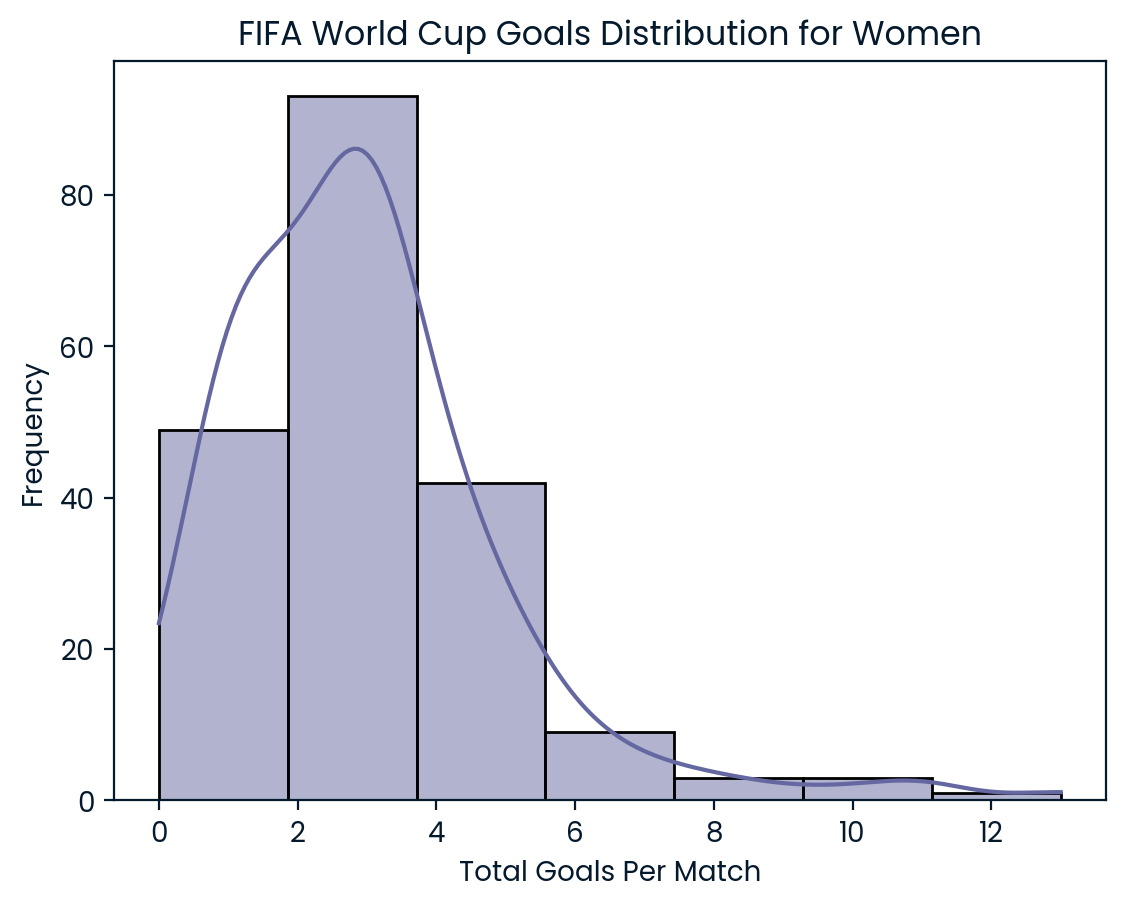

In [123]:
#Determining if data is normally distributed
sns.histplot(df_women_wc['total_goals'], bins=7, kde=True)
plt.xlabel('Total Goals Per Match')
plt.ylabel('Frequency')
plt.title('FIFA World Cup Goals Distribution for Women')
plt.show()

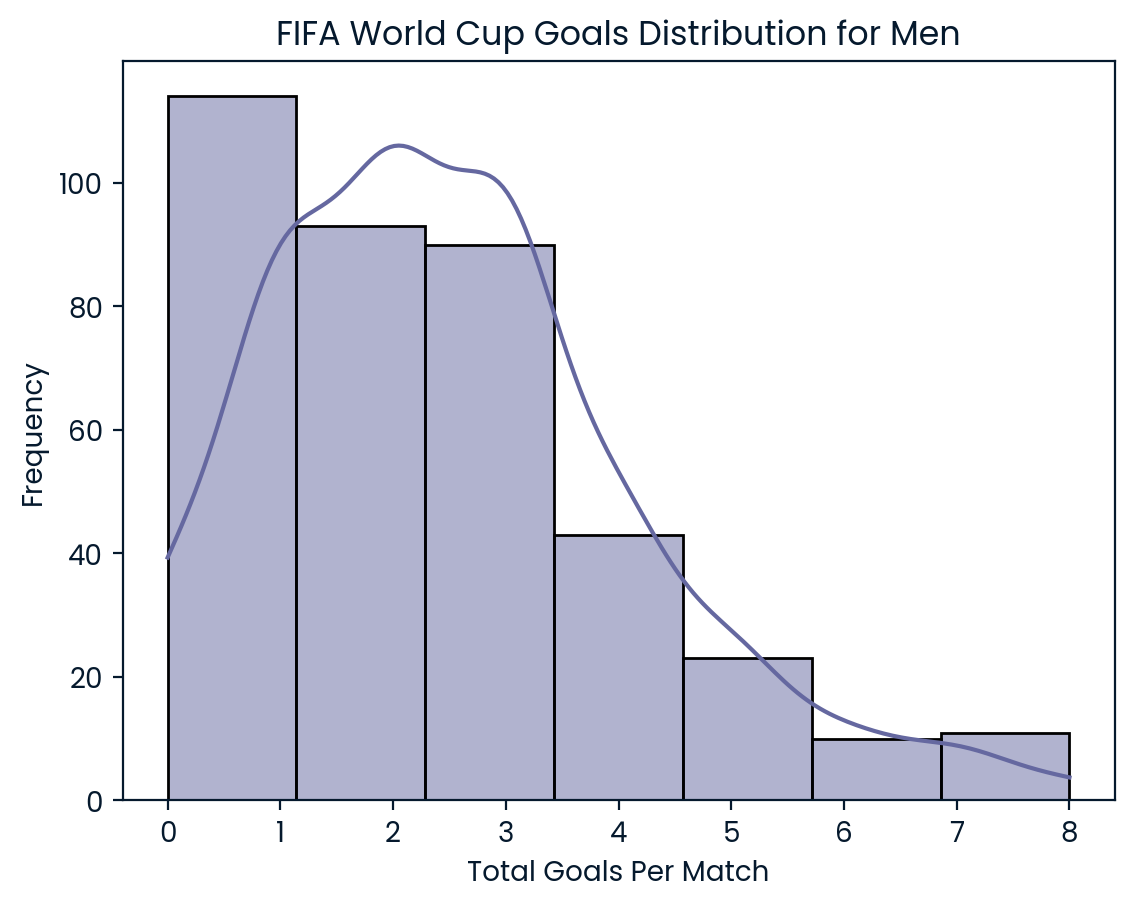

In [124]:
sns.histplot(df_men_wc['total_goals'],bins=7, kde=True)
plt.xlabel('Total Goals Per Match')
plt.ylabel('Frequency')
plt.title('FIFA World Cup Goals Distribution for Men')
plt.show()

## It's observed that the date is not normally distributed for either but we can further attest to this by running a test of normality such as the Shapiro-Wilk test.

In [125]:
# Shapiro-Wilk test for normality on total goals in Women's World Cup
stat_women, p_women = shapiro(df_women_wc['total_goals'])

# Shapiro-Wilk test for normality on total goals in Men's World Cup
stat_men, p_men = shapiro(df_men_wc['total_goals'])

# Print and interpret results for Women's World Cup
print(f"Women's World Cup - Shapiro-Wilk test statistic: {stat_women}, p-value: {p_women}")
if p_women < 0.10:
    print("Data is not normally distributed (reject H0).")
else:
    print("Data is likely normally distributed (fail to reject H0).")

# Print and interpret results for Men's World Cup
print(f"Men's World Cup - Shapiro-Wilk test statistic: {stat_men}, p-value: {p_men}")
if p_men < 0.10:
    print("Data is not normally distributed (reject H0).")
else:
    print("Data is likely normally distributed (fail to reject H0).")

Women's World Cup - Shapiro-Wilk test statistic: 0.8491013050079346, p-value: 3.8905201759850683e-13
Data is not normally distributed (reject H0).
Men's World Cup - Shapiro-Wilk test statistic: 0.9266489744186401, p-value: 8.894154401688226e-13
Data is not normally distributed (reject H0).


## Since both groups aren't normally distributed, the test to be used will be a Wilcoxon-Mann-Whitney test.

In [126]:
#Running the Mann-Whitney U test with a 10% significance levek
results = pg.mwu(df_women_wc['total_goals'],df_men_wc['total_goals'], alternative='greater')
print(results)

       U-val alternative     p-val       RBC      CLES
MWU  43273.0     greater  0.005107 -0.126901  0.563451


In [127]:
#Extract the P-Value and determine whether to reject or fail to reject null hypothesis
p_val = results['p-val'].to_numpy()  

alpha = 0.10

if p_val < alpha:
    result = "reject"
else:
    result = "fail to reject"
print(result)

result_dict = {"p_val": p_val, "result": result}

reject
